In [1]:
import os
import numpy as np
import csv
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import math
import time
import nltk
import tensorflow as tf
from tensorflow.keras.layers import GRU, LSTM, Bidirectional, Dense, Flatten, Conv1D, BatchNormalization, LeakyReLU, Dropout
from tensorflow.keras import Sequential
from tensorflow.keras.utils import plot_model
from pickle import load
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
import statsmodels.api as sm
from math import sqrt
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from pickle import dump
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import unicodedata
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
all_tweets = pd.read_csv('stock_tweets.csv')

In [3]:
print(all_tweets.shape)
all_tweets['Stock Name'].unique()

(80793, 4)


array(['TSLA', 'MSFT', 'PG', 'META', 'AMZN', 'GOOG', 'AMD', 'AAPL',
       'NFLX', 'TSM', 'KO', 'F', 'COST', 'DIS', 'VZ', 'CRM', 'INTC', 'BA',
       'BX', 'NOC', 'PYPL', 'ENPH', 'NIO', 'ZS', 'XPEV'], dtype=object)

In [5]:
df = all_tweets #[all_tweets['Stock Name'].isin(stock_names)]
print(df.shape)
df.head()

(80793, 4)


,Date,Tweet,Stock Name,Company Name
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc."
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc."
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc."
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,"Tesla, Inc."
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,"Tesla, Inc."


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80793 entries, 0 to 80792
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          80793 non-null  object
 1   Tweet         80793 non-null  object
 2   Stock Name    80793 non-null  object
 3   Company Name  80793 non-null  object
dtypes: object(4)
memory usage: 2.5+ MB


Date            0
Tweet           0
Stock Name      0
Company Name    0
dtype: int64

In [6]:
df['Stock Name'].value_counts()

Stock Name
TSLA    37422
TSM     11034
AAPL     5056
PG       4089
AMZN     4089
MSFT     4089
NIO      3021
META     2751
AMD      2227
NFLX     1727
GOOG     1291
PYPL      843
DIS       635
BA        399
COST      393
INTC      315
KO        310
CRM       233
XPEV      225
ENPH      216
ZS        193
VZ        123
BX         50
NOC        31
F          31
Name: count, dtype: int64

In [6]:
sent_df = df.copy()
sent_df["sentiment_score"] = ''
sent_df["Negative"] = ''
sent_df["Neutral"] = ''
sent_df["Positive"] = ''
sent_df.head()

,Date,Tweet,Stock Name,Company Name,sentiment_score,Negative,Neutral,Positive
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc.",,,,
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc.",,,,
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc.",,,,
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,"Tesla, Inc.",,,,
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,"Tesla, Inc.",,,,


To get sentiment (polarity) scores, we use **VADER (Valence Aware Dictionary for Sentiment Reasoning)** model. VADER is a model used for text sentiment analysis that is sensitive to both polarity (positive/negative) and intensity (strength) of emotion. It is available in the NLTK package and can be applied directly to unlabeled text data.

VADER sentimental analysis relies on a dictionary that maps lexical features to emotion intensities known as sentiment scores. The sentiment score of a text can be obtained by summing up the intensity of each word in the text.

In [7]:
%%time
sentiment_analyzer = SentimentIntensityAnalyzer()
for indx, row in sent_df.iterrows():
    try:
        sentence_i = unicodedata.normalize('NFKD', sent_df.loc[indx, 'Tweet'])
        sentence_sentiment = sentiment_analyzer.polarity_scores(sentence_i)
        sent_df.at[indx, 'sentiment_score'] = sentence_sentiment['compound']
        sent_df.at[indx, 'Negative'] = sentence_sentiment['neg']
        sent_df.at[indx, 'Neutral'] = sentence_sentiment['neu']
        sent_df.at[indx, 'Positive'] = sentence_sentiment['pos']
    except TypeError:
        print (sent_df.loc[indx, 'Tweet'])
        print (indx)
        break

CPU times: user 13.1 s, sys: 80 ms, total: 13.2 s
Wall time: 13.2 s


In [8]:
sent_df = sent_df.drop(columns=['Company Name'])

In [10]:
sent_df.head()

,Date,Tweet,Stock Name,sentiment_score,Negative,Neutral,Positive
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,0.0772,0.127,0.758,0.115
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,0.0,0.0,1.0,0.0
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,0.296,0.0,0.951,0.049
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,-0.7568,0.273,0.59,0.137
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,-0.875,0.526,0.474,0.0


In [12]:
# Define a function to filter DataFrame based on time range
def filter_time_range(df, start_time, end_time):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Time'] = df['Date'].dt.time
    df['DateTime'] = df['Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Time'].astype(str)
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    return df[(df['Time'] >= start_time) & (df['Time'] <= end_time)]

# Define the time ranges in EST
start_time_est = pd.Timestamp('05:30:00').time()
end_time_est = pd.Timestamp('12:30:00').time()

# Filter DataFrame for two different time ranges
df_within_time_range = filter_time_range(sent_df, start_time_est, end_time_est)
df_outside_time_range = sent_df[~sent_df.index.isin(df_within_time_range.index)]

df_within_time_range['Date'] = pd.to_datetime(df_within_time_range['Date'])
df_within_time_range['Date'] = df_within_time_range['Date'].dt.date

df_outside_time_range['Date'] = pd.to_datetime(df_outside_time_range['Date'])
df_outside_time_range['Date'] = df_outside_time_range['Date'].dt.date

# Aggregate sentiment scores for both time ranges
result_within_time_range = df_within_time_range.groupby(['Stock Name', 'Date']).agg({'sentiment_score': ['mean', 'min', 'max', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]}).reset_index()
result_within_time_range.columns = ['Stock Name', 'Date', 'Mean', 'Min', 'Max', '25th Percentile', '75th Percentile']

result_outside_time_range = df_outside_time_range.groupby(['Stock Name', 'Date']).agg({'sentiment_score': ['mean', 'min', 'max', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]}).reset_index()
result_outside_time_range.columns = ['Stock Name', 'Date', 'Mean', 'Min', 'Max', '25th Percentile', '75th Percentile']

print("Results for time range between 5:30 AM EST to 12:30 PM EST:")
print(result_within_time_range)

print("\nResults for time range outside 5:30 AM EST to 12:30 PM EST:")
print(result_outside_time_range)


Results for time range between 5:30 AM EST to 12:30 PM EST:
     Stock Name        Date    Mean     Min     Max  25th Percentile  \
0          AAPL  2021-09-30  0.2739  0.2296  0.3182          0.25175   
1          AAPL  2021-10-07  0.1484     0.0   0.368          0.03860   
2          AAPL  2021-10-08  0.7842  0.7778  0.7906          0.78100   
3          AAPL  2021-10-10  0.3612  0.3612  0.3612          0.36120   
4          AAPL  2021-10-13 -0.4278 -0.4278 -0.4278         -0.42780   
...         ...         ...     ...     ...     ...              ...   
2503         ZS  2022-08-30     0.0     0.0     0.0          0.00000   
2504         ZS  2022-09-01  0.7351  0.7351  0.7351          0.73510   
2505         ZS  2022-09-17  0.8271  0.8271  0.8271          0.82710   
2506         ZS  2022-09-21  0.5122  0.5122  0.5122          0.51220   
2507         ZS  2022-09-29     0.0     0.0     0.0          0.00000   

      75th Percentile  
0             0.29605  
1             0.22260  
2  

In [13]:
sent_df[sent_df['Date'].dt.date == pd.to_datetime('2021-10-13').date()]

,Date,Tweet,Stock Name,sentiment_score,Negative,Neutral,Positive,Time,DateTime
36103,2021-10-13 23:17:31+00:00,"If $TSLA reaches $4,000 by 2025, do the math o...",TSLA,0.4404,0.0,0.83,0.17,23:17:31,2021-10-13 23:17:31
36104,2021-10-13 22:44:18+00:00,Highest $TSLA close in the last 243 days🙌🏻 htt...,TSLA,0.0,0.0,1.0,0.0,22:44:18,2021-10-13 22:44:18
36105,2021-10-13 22:40:15+00:00,"Out of 3,922,516 people \n862,953.52 said no \...",TSLA,0.6083,0.09,0.657,0.253,22:40:15,2021-10-13 22:40:15
36106,2021-10-13 22:28:30+00:00,"@Kristennetten @Tesla @elonmusk Remember, Tabl...",TSLA,0.3182,0.0,0.947,0.053,22:28:30,2021-10-13 22:28:30
36107,2021-10-13 22:00:21+00:00,Another distracted driver crashing into emerge...,TSLA,-0.6124,0.312,0.688,0.0,22:00:21,2021-10-13 22:00:21
...,...,...,...,...,...,...,...,...,...
80272,2021-10-13 08:45:25+00:00,🚨 $NIO NEO Park Constructions 🚧 🦺 🏗 Update.\n\...,NIO,0.8221,0.0,0.833,0.167,08:45:25,2021-10-13 08:45:25
80562,2021-10-13 19:48:24+00:00,Todays plays 🐼\n\n$SPOT 240c hit +77% (2.65 to...,ZS,0.25,0.0,0.962,0.038,19:48:24,2021-10-13 19:48:24
80563,2021-10-13 15:18:31+00:00,The good and bad about this market. Indexes ar...,ZS,0.836,0.095,0.713,0.192,15:18:31,2021-10-13 15:18:31
80564,2021-10-13 14:55:31+00:00,$PANW raro entre las CyberSecurity $ZS $FTNT $...,ZS,0.0,0.0,1.0,0.0,14:55:31,2021-10-13 14:55:31


In [13]:
# Merge results on 'Stock Name' and 'Date'
merged_result = pd.merge(result_within_time_range, result_outside_time_range, on=['Stock Name', 'Date'], suffixes=('_sentiment_intraday', '_outside'))

print(merged_result)

     Stock Name        Date Mean_sentiment_intraday Min_sentiment_intraday  \
0          AAPL  2021-09-30                  0.2739                 0.2296   
1          AAPL  2021-10-07                  0.1484                    0.0   
2          AAPL  2021-10-08                  0.7842                 0.7778   
3          AAPL  2021-10-10                  0.3612                 0.3612   
4          AAPL  2021-10-13                 -0.4278                -0.4278   
...         ...         ...                     ...                    ...   
2335         ZS  2022-01-07                  0.4927                 0.4927   
2336         ZS  2022-02-01                     0.0                    0.0   
2337         ZS  2022-02-22                     0.0                    0.0   
2338         ZS  2022-05-21                 -0.3382                -0.3382   
2339         ZS  2022-09-01                  0.7351                 0.7351   

     Max_sentiment_intraday  25th Percentile_sentiment_intraday

In [14]:
merged_result['Mean_sentiment_before_sod']=merged_result['Mean_outside'].shift(-1) # return a day before the news
merged_result['Min_sentiment_before_sod']=merged_result['Min_outside'].shift(-1)
merged_result['Max_sentiment_before_sod']=merged_result['Max_outside'].shift(-1)
merged_result['25th Percentile_sentiment_before_sod']=merged_result['25th Percentile_outside'].shift(-1)
merged_result['75th Percentile_sentiment_before_sod']=merged_result['75th Percentile_outside'].shift(-1)
merged_result.reset_index(level=0, inplace=True)



In [15]:
tweet_ds = merged_result.drop(['25th Percentile_outside', '75th Percentile_outside', 'Mean_outside', 'Min_outside', 'Max_outside', '25th Percentile_sentiment_intraday', '75th Percentile_sentiment_intraday', '25th Percentile_sentiment_before_sod', '75th Percentile_sentiment_before_sod'], axis=1)
tweet_ds.head()

,index,Stock Name,Date,Mean_sentiment_intraday,Min_sentiment_intraday,Max_sentiment_intraday,Mean_sentiment_before_sod,Min_sentiment_before_sod,Max_sentiment_before_sod
0,0,AAPL,2021-09-30,0.2739,0.2296,0.3182,0.39536,0.0,0.6892
1,1,AAPL,2021-10-07,0.1484,0.0,0.368,0.32482,0.0,0.8538
2,2,AAPL,2021-10-08,0.7842,0.7778,0.7906,0.231475,-0.4215,0.8597
3,3,AAPL,2021-10-10,0.3612,0.3612,0.3612,-0.01315,-0.5859,0.2023
4,4,AAPL,2021-10-13,-0.4278,-0.4278,-0.4278,0.516231,0.0,0.893


As the result of sentiment analysis we get average polarity scores of all tweets about a cartain stock ticker for each day:

<a id="section-three"></a>
# Get final dataset for training

In [9]:
all_stocks = pd.read_csv('stock_yfinance_data.csv')
print(all_stocks.shape)
all_stocks.head()
all_stocks['Stock Name'].unique()
all_stocks

(6300, 8)


,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA
...,...,...,...,...,...,...,...,...
6295,2022-09-23,13.090000,13.892000,12.860000,13.710000,13.710000,28279600,XPEV
6296,2022-09-26,14.280000,14.830000,14.070000,14.370000,14.370000,27891300,XPEV
6297,2022-09-27,14.580000,14.800000,13.580000,13.710000,13.710000,21160800,XPEV
6298,2022-09-28,13.050000,13.421000,12.690000,13.330000,13.330000,31799400,XPEV


In [10]:
stock_df = all_stocks
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df['Date'] = stock_df['Date'].dt.date

In [11]:
stock_df.columns
stock_df['Stock Name'].unique()

array(['TSLA', 'MSFT', 'PG', 'META', 'AMZN', 'GOOG', 'AMD', 'AAPL',
       'NFLX', 'TSM', 'KO', 'F', 'COST', 'DIS', 'VZ', 'CRM', 'INTC', 'BA',
       'BX', 'NOC', 'PYPL', 'ENPH', 'NIO', 'ZS', 'XPEV'], dtype=object)

In [16]:
final_df = pd.merge(stock_df, tweet_ds, on=['Stock Name', 'Date'])
print(final_df.shape)

(1743, 15)


In [23]:
final_df['Stock Name'].value_counts()

Stock Name
TSLA    252
TSM     206
NIO     193
AAPL    174
PG      152
AMZN    152
MSFT    152
META    100
AMD      97
GOOG     86
NFLX     48
PYPL     28
DIS      21
INTC     18
XPEV     16
BA       11
COST      9
KO        8
ZS        7
CRM       5
VZ        3
ENPH      2
BX        1
NOC       1
F         1
Name: count, dtype: int64

In [17]:
final_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name,index,Mean_sentiment_intraday,Min_sentiment_intraday,Max_sentiment_intraday,Mean_sentiment_before_sod,Min_sentiment_before_sod,Max_sentiment_before_sod
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA,1654,0.228995,-0.9423,0.8331,0.21787,-0.8689,0.9313
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA,1655,0.277408,-0.8176,0.9305,0.272467,-0.8217,0.9632
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA,1658,0.07683,-0.5766,0.7278,0.090785,-0.8885,0.9467
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA,1659,0.009139,-0.875,0.7003,0.219249,-0.6908,0.9732
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA,1660,0.147529,-0.5267,0.8122,0.187267,-0.9169,0.923


In [18]:
def event_return(df):
    #Computing the return
    df['close_pct_change'] = df['Close'].pct_change()
    df['vol_pct_change'] = df['Volume'].pct_change()
    
    df['high_low_diff'] = df['High'] - df['Low']
    df['open_close_diff'] = df['Open'] - df['Close']
    
    
    df['market_up'] = df['Open'] - df['Close']
    df['vol_weekly_diff'] = df['Volume'].shift(7)
    
    df['ret_curr'] = df['High'] - df['Low']

    #Computing the event return
    rtm1 = df['ret_curr'].shift(-1) # return a day before the news
    rtp1 = df['ret_curr'].shift(1) # return a day after the news
    rt = df['ret_curr'] # return the day of the news

    df['eventRet'] = rt + rtp1 
    df.reset_index(level=0, inplace=True)

    df['date'] = pd.to_datetime(df['Date']).apply(lambda x: x.date())

In [19]:
event_return(final_df)

In [20]:
cpc = final_df['close_pct_change'].dropna()
min(cpc)

-0.8351226281268689

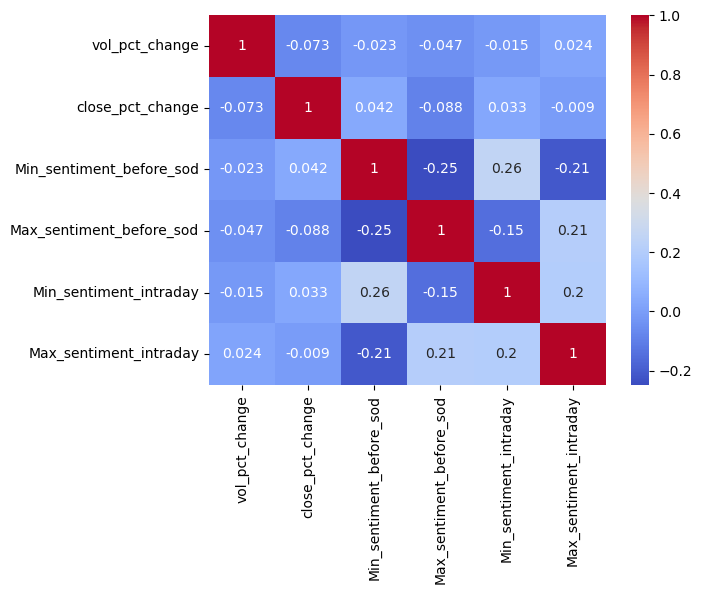

In [21]:
related_cols = ['vol_pct_change', 'close_pct_change', 'Min_sentiment_before_sod', 'Max_sentiment_before_sod', 'Min_sentiment_intraday', 'Max_sentiment_intraday']
sns.heatmap(final_df[related_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [22]:
# Define a function to apply the condition element-wise
def classify_movement(change):
    if change > 0.05:
        return 1
    elif change < -0.05:
        return -1
    else :
        return 0
# Apply the function to each value in the 'close_pct_change' column
final_df['market_movement'] = final_df['close_pct_change'].apply(classify_movement)

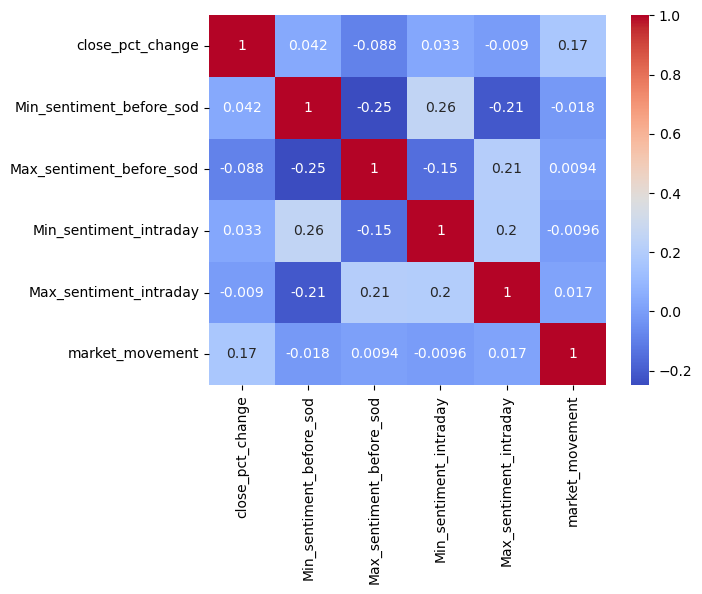

In [23]:
final_df['market_movement'].value_counts()

final_df['market_movement'].value_counts()
required_cols = ['close_pct_change', 'Min_sentiment_before_sod', 'Max_sentiment_before_sod', 'Min_sentiment_intraday', 'Max_sentiment_intraday', 'market_movement']

final_market_df = final_df[required_cols]
sns.heatmap(final_market_df[required_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [24]:
# Handling missing values
final_market_df.dropna(inplace=True) 

# Resetting index
final_market_df.reset_index(drop=True, inplace=True)